dataset link - https://archive.ics.uci.edu/dataset/174/parkinsons

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

In [ ]:
from sklearn.preprocessing import RobustScaler, MinMaxScaler, MaxAbsScaler, Normalizer, StandardScaler, PowerTransformer, QuantileTransformer
from imblearn.over_sampling import SMOTE
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
pip install ucimlrepo

In [ ]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
parkinsons = fetch_ucirepo(id=174)

# data (as pandas dataframes)
X = parkinsons.data.features
y = parkinsons.data.targets

# metadata
print(parkinsons.metadata)

# variable information
print(parkinsons.variables)


{'uci_id': 174, 'name': 'Parkinsons', 'repository_url': 'https://archive.ics.uci.edu/dataset/174/parkinsons', 'data_url': 'https://archive.ics.uci.edu/static/public/174/data.csv', 'abstract': "Oxford Parkinson's Disease Detection Dataset", 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 197, 'num_features': 22, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['status'], 'index_col': ['name'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2007, 'last_updated': 'Wed Feb 14 2024', 'dataset_doi': '10.24432/C59C74', 'creators': ['Max Little'], 'intro_paper': {'ID': 385, 'type': 'NATIVE', 'title': 'Exploiting Nonlinear Recurrence and Fractal Scaling Properties for Voice Disorder Detection', 'authors': 'Max A. Little, P. McSharry, S. Roberts, D. Costello, I. Moroz', 'venue': 'BioMedical Engineering OnLine', 'year': 2007, 'journal': None, 'DOI': '10.1186/1475-925X-6-23', 'URL

In [ ]:
print(X.shape)

(195, 22)


In [ ]:
print(y.shape)

(195, 1)


In [ ]:
X.head()

,MDVP:Fo,MDVP:Fhi,MDVP:Flo,MDVP:Jitter,MDVP:Jitter,MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer,...,MDVP:APQ,Shimmer:DDA,NHR,HNR,RPDE,DFA,spread1,spread2,D2,PPE
0,119.992,157.302,74.997,0.00784,0.00784,0.00370,0.00554,0.01109,0.04374,0.04374,...,0.02971,0.06545,0.02211,21.033,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
1,122.400,148.650,113.819,0.00968,0.00968,0.00465,0.00696,0.01394,0.06134,0.06134,...,0.04368,0.09403,0.01929,19.085,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
2,116.682,131.111,111.555,0.01050,0.01050,0.00544,0.00781,0.01633,0.05233,0.05233,...,0.03590,0.08270,0.01309,20.651,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
3,116.676,137.871,111.366,0.00997,0.00997,0.00502,0.00698,0.01505,0.05492,0.05492,...,0.03772,0.08771,0.01353,20.644,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975
4,116.014,141.781,110.655,0.01284,0.01284,0.00655,0.00908,0.01966,0.06425,0.06425,...,0.04465,0.10470,0.01767,19.649,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335


In [ ]:
X.tail()


,MDVP:Fo,MDVP:Fhi,MDVP:Flo,MDVP:Jitter,MDVP:Jitter,MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer,...,MDVP:APQ,Shimmer:DDA,NHR,HNR,RPDE,DFA,spread1,spread2,D2,PPE
190,174.188,230.978,94.261,0.00459,0.00459,0.00263,0.00259,0.00790,0.04087,0.04087,...,0.02745,0.07008,0.02764,19.517,0.448439,0.657899,-6.538586,0.121952,2.657476,0.133050
191,209.516,253.017,89.488,0.00564,0.00564,0.00331,0.00292,0.00994,0.02751,0.02751,...,0.01879,0.04812,0.01810,19.147,0.431674,0.683244,-6.195325,0.129303,2.784312,0.168895
192,174.688,240.005,74.287,0.01360,0.01360,0.00624,0.00564,0.01873,0.02308,0.02308,...,0.01667,0.03804,0.10715,17.883,0.407567,0.655683,-6.787197,0.158453,2.679772,0.131728
193,198.764,396.961,74.904,0.00740,0.00740,0.00370,0.00390,0.01109,0.02296,0.02296,...,0.01588,0.03794,0.07223,19.020,0.451221,0.643956,-6.744577,0.207454,2.138608,0.123306
194,214.289,260.277,77.973,0.00567,0.00567,0.00295,0.00317,0.00885,0.01884,0.01884,...,0.01373,0.03078,0.04398,21.209,0.462803,0.664357,-5.724056,0.190667,2.555477,0.148569


In [ ]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 22 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   MDVP:Fo       195 non-null    float64
 1   MDVP:Fhi      195 non-null    float64
 2   MDVP:Flo      195 non-null    float64
 3   MDVP:Jitter   195 non-null    float64
 4   MDVP:Jitter   195 non-null    float64
 5   MDVP:RAP      195 non-null    float64
 6   MDVP:PPQ      195 non-null    float64
 7   Jitter:DDP    195 non-null    float64
 8   MDVP:Shimmer  195 non-null    float64
 9   MDVP:Shimmer  195 non-null    float64
 10  Shimmer:APQ3  195 non-null    float64
 11  Shimmer:APQ5  195 non-null    float64
 12  MDVP:APQ      195 non-null    float64
 13  Shimmer:DDA   195 non-null    float64
 14  NHR           195 non-null    float64
 15  HNR           195 non-null    float64
 16  RPDE          195 non-null    float64
 17  DFA           195 non-null    float64
 18  spread1       195 non-null    

In [ ]:
#checking the missing values
X.isnull().sum()

,0
MDVP:Fo,0
MDVP:Fhi,0
MDVP:Flo,0
MDVP:Jitter,0
MDVP:Jitter,0
MDVP:RAP,0
MDVP:PPQ,0
Jitter:DDP,0
MDVP:Shimmer,0
MDVP:Shimmer,0


In [ ]:
X.describe()

,MDVP:Fo,MDVP:Fhi,MDVP:Flo,MDVP:Jitter,MDVP:Jitter,MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer,...,MDVP:APQ,Shimmer:DDA,NHR,HNR,RPDE,DFA,spread1,spread2,D2,PPE
count,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,...,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000
mean,154.228641,197.104918,116.324631,0.006220,0.006220,0.003306,0.003446,0.009920,0.029709,0.029709,...,0.024081,0.046993,0.024847,21.885974,0.498536,0.718099,-5.684397,0.226510,2.381826,0.206552
std,41.390065,91.491548,43.521413,0.004848,0.004848,0.002968,0.002759,0.008903,0.018857,0.018857,...,0.016947,0.030459,0.040418,4.425764,0.103942,0.055336,1.090208,0.083406,0.382799,0.090119
min,88.333000,102.145000,65.476000,0.001680,0.001680,0.000680,0.000920,0.002040,0.009540,0.009540,...,0.007190,0.013640,0.000650,8.441000,0.256570,0.574282,-7.964984,0.006274,1.423287,0.044539
25%,117.572000,134.862500,84.291000,0.003460,0.003460,0.001660,0.001860,0.004985,0.016505,0.016505,...,0.013080,0.024735,0.005925,19.198000,0.421306,0.674758,-6.450096,0.174351,2.099125,0.137451
50%,148.790000,175.829000,104.315000,0.004940,0.004940,0.002500,0.002690,0.007490,0.022970,0.022970,...,0.018260,0.038360,0.011660,22.085000,0.495954,0.722254,-5.720868,0.218885,2.361532,0.194052
75%,182.769000,224.205500,140.018500,0.007365,0.007365,0.003835,0.003955,0.011505,0.037885,0.037885,...,0.029400,0.060795,0.025640,25.075500,0.587562,0.761881,-5.046192,0.279234,2.636456,0.252980
max,260.105000,592.030000,239.170000,0.033160,0.033160,0.021440,0.019580,0.064330,0.119080,0.119080,...,0.137780,0.169420,0.314820,33.047000,0.685151,0.825288,-2.434031,0.450493,3.671155,0.527367


In [ ]:
y.value_counts()

,count
status,
1,147
0,48


In [ ]:
parkinsons_df = X.copy()
parkinsons_df['status'] = y
#combining x and y

In [ ]:
parkinsons_df.groupby('status').mean(numeric_only=True)


,MDVP:Fo,MDVP:Fhi,MDVP:Flo,MDVP:Jitter,MDVP:Jitter,MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer,...,MDVP:APQ,Shimmer:DDA,NHR,HNR,RPDE,DFA,spread1,spread2,D2,PPE
status,,,,,,,,,,,,,,,,,,,,,
0,181.937771,223.636750,145.207292,0.003866,0.003866,0.001925,0.002056,0.005776,0.017615,0.017615,...,0.013305,0.028511,0.011483,24.678750,0.442552,0.695716,-6.759264,0.160292,2.154491,0.123017
1,145.180762,188.441463,106.893558,0.006989,0.006989,0.003757,0.003900,0.011273,0.033658,0.033658,...,0.027600,0.053027,0.029211,20.974048,0.516816,0.725408,-5.333420,0.248133,2.456058,0.233828


# DATA VISUALISATION

* histogram

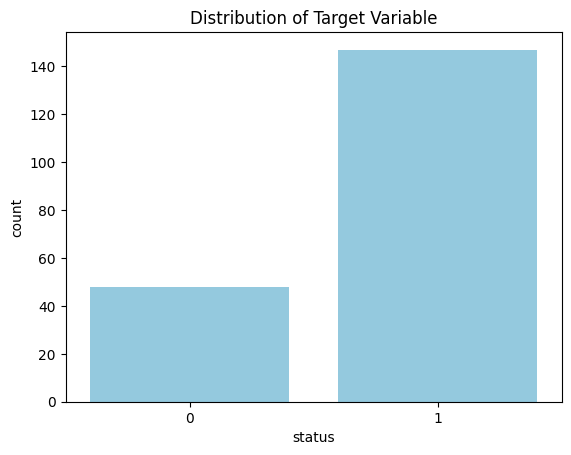

In [ ]:
sns.countplot(x='status', data=parkinsons_df, color='skyblue')
plt.title('Distribution of Target Variable')
plt.show()


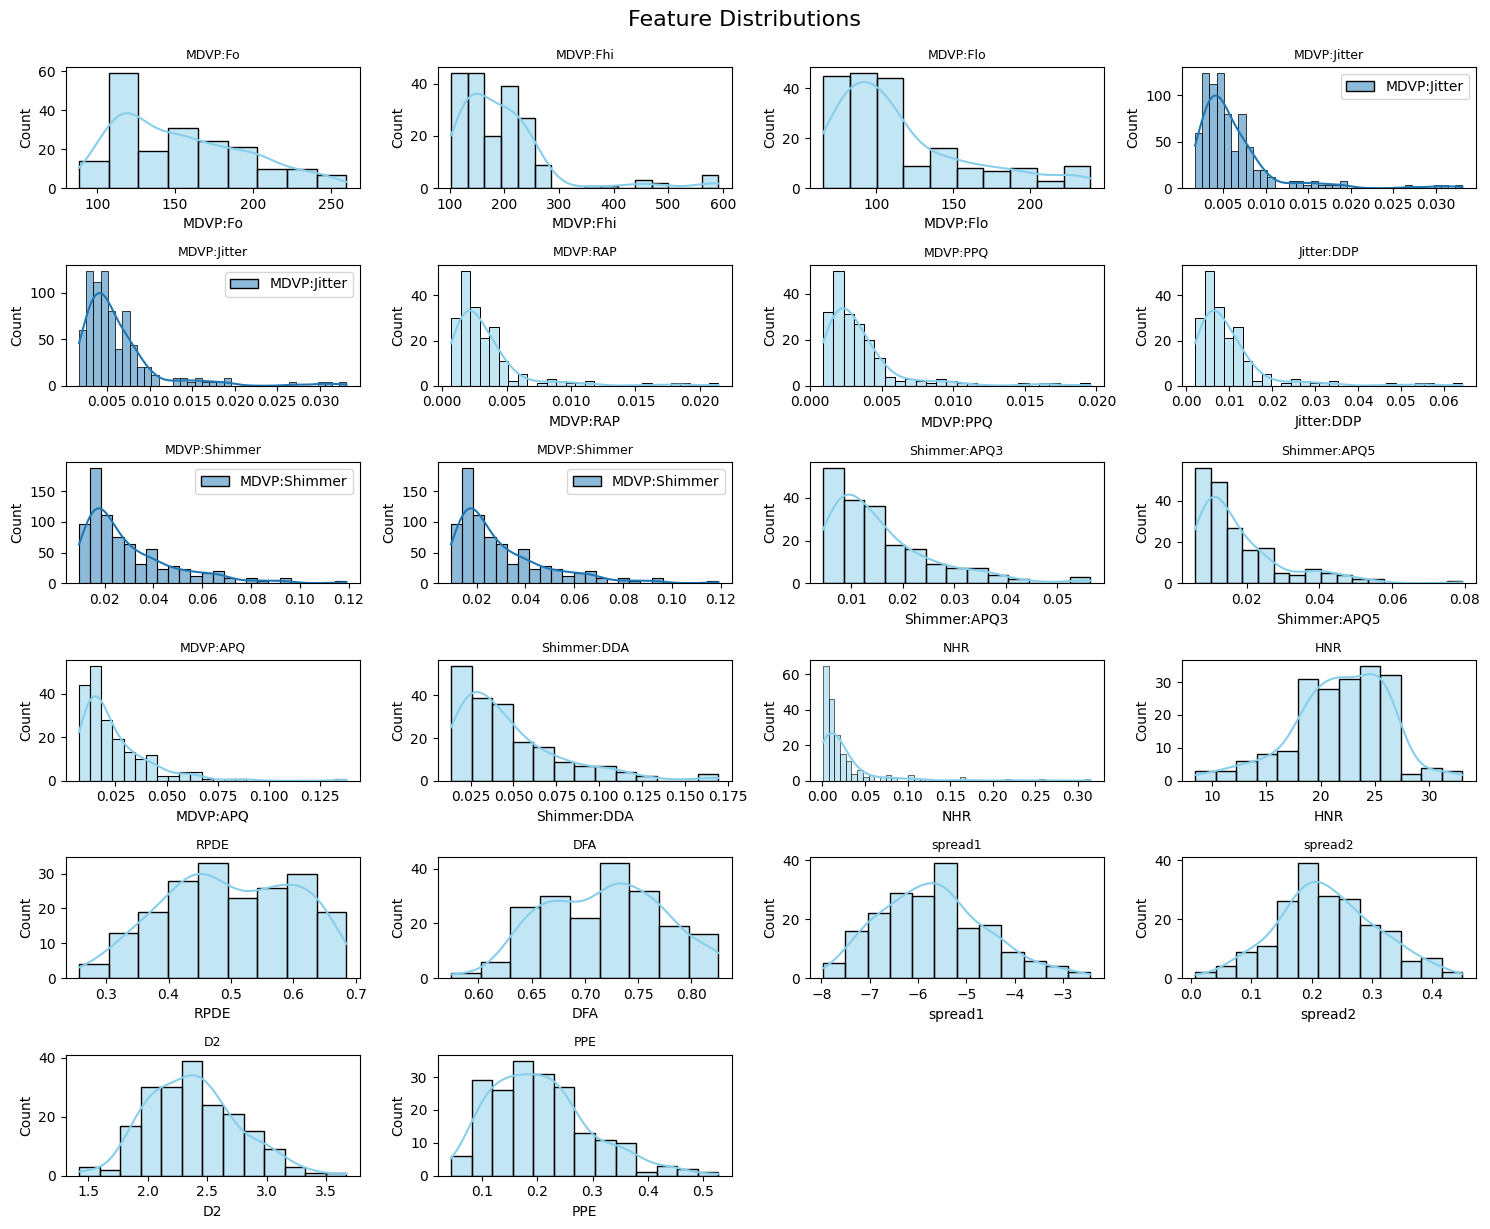

In [ ]:
plt.figure(figsize=(15,12))
for i, col in enumerate(X.columns, 1):
    plt.subplot(6, 4, i)
    sns.histplot(X[col], kde=True, color="skyblue", edgecolor="black")
    plt.title(col, fontsize=9)
    plt.tight_layout()

plt.suptitle("Feature Distributions", fontsize=16, y=1.02)
plt.show()


* BOX PLOT

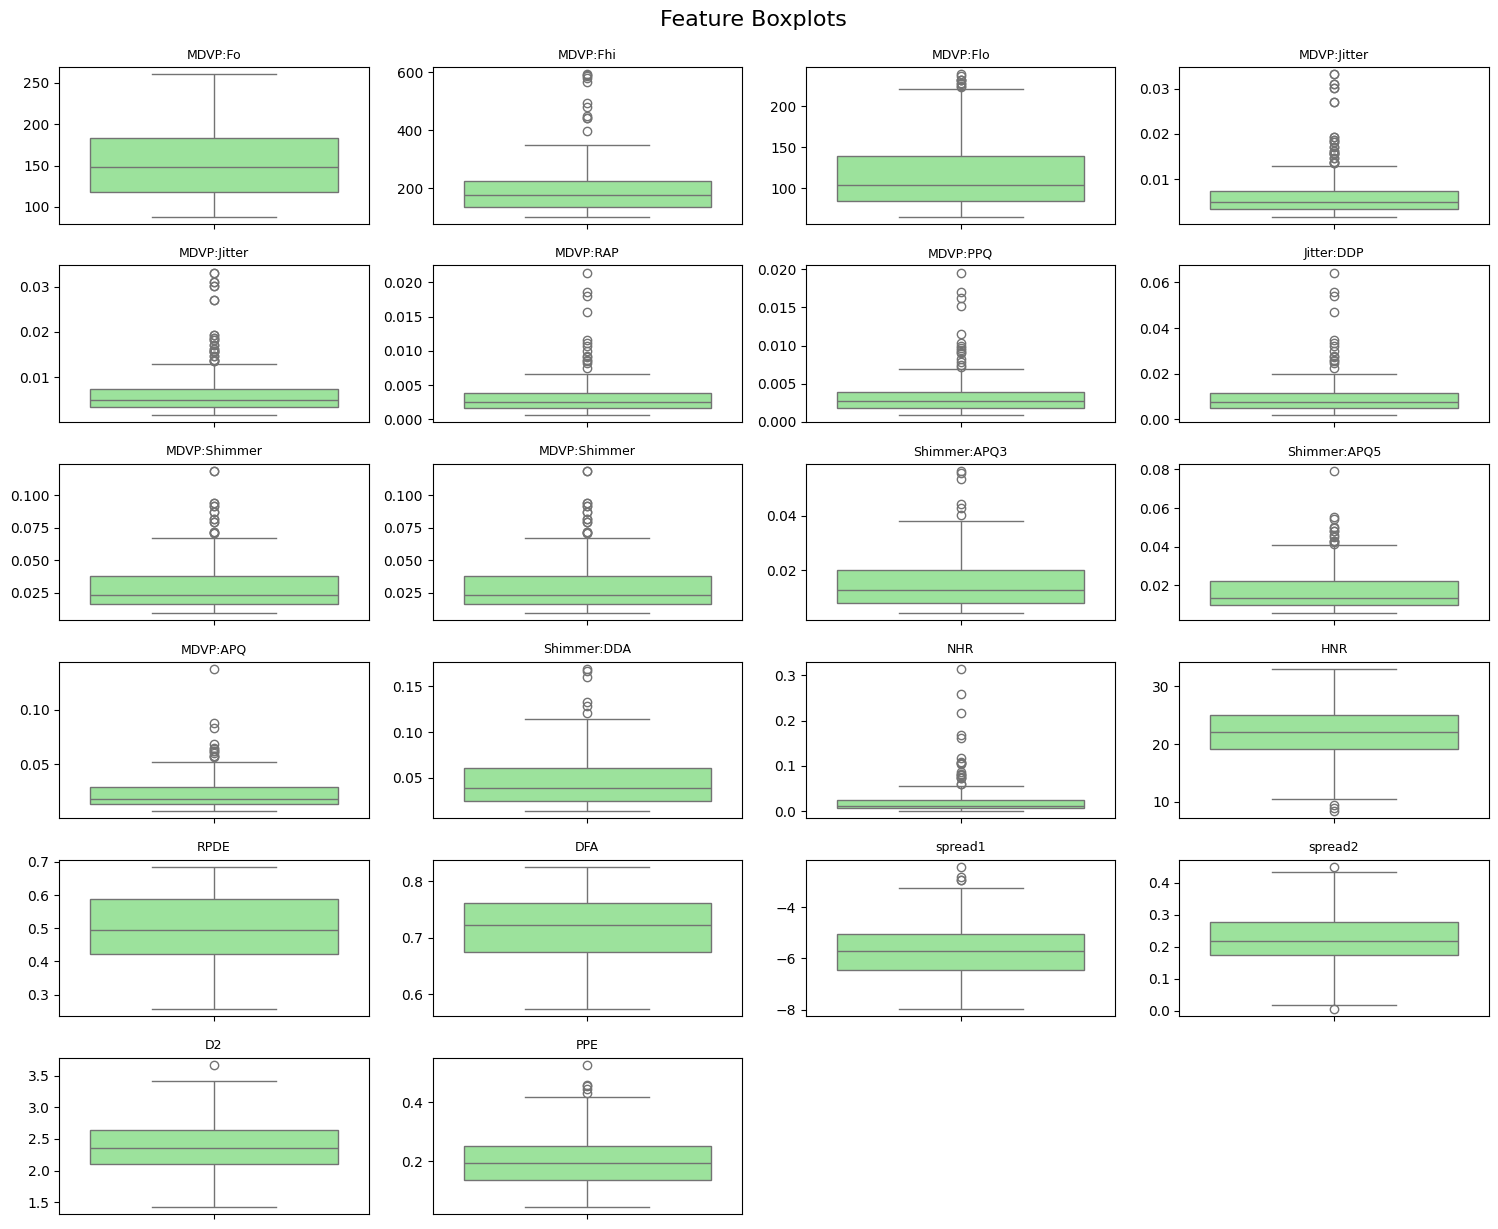

In [ ]:
plt.figure(figsize=(15, 12))
for i, col in enumerate(X.columns, 1):
    plt.subplot(6, 4, i)
    sns.boxplot(y=X[col].values.flatten(), color='lightgreen')
    plt.title(col, fontsize=9)
plt.tight_layout()
plt.suptitle("Feature Boxplots", size=16, y=1.02)
plt.show()


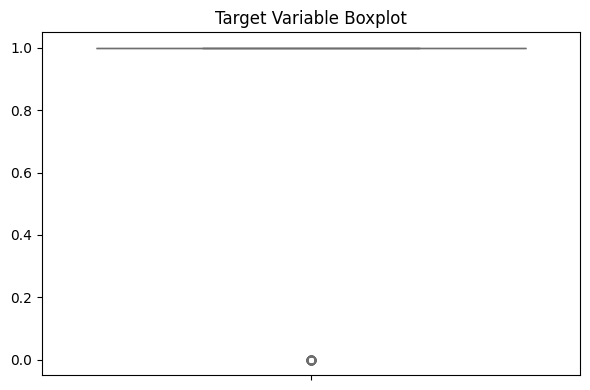

In [ ]:

plt.figure(figsize=(6, 4))
sns.boxplot(y=y.values.flatten(), color='lightcoral')
plt.title("Target Variable Boxplot", fontsize=12)
plt.tight_layout()
plt.show()


* correlation heatmap

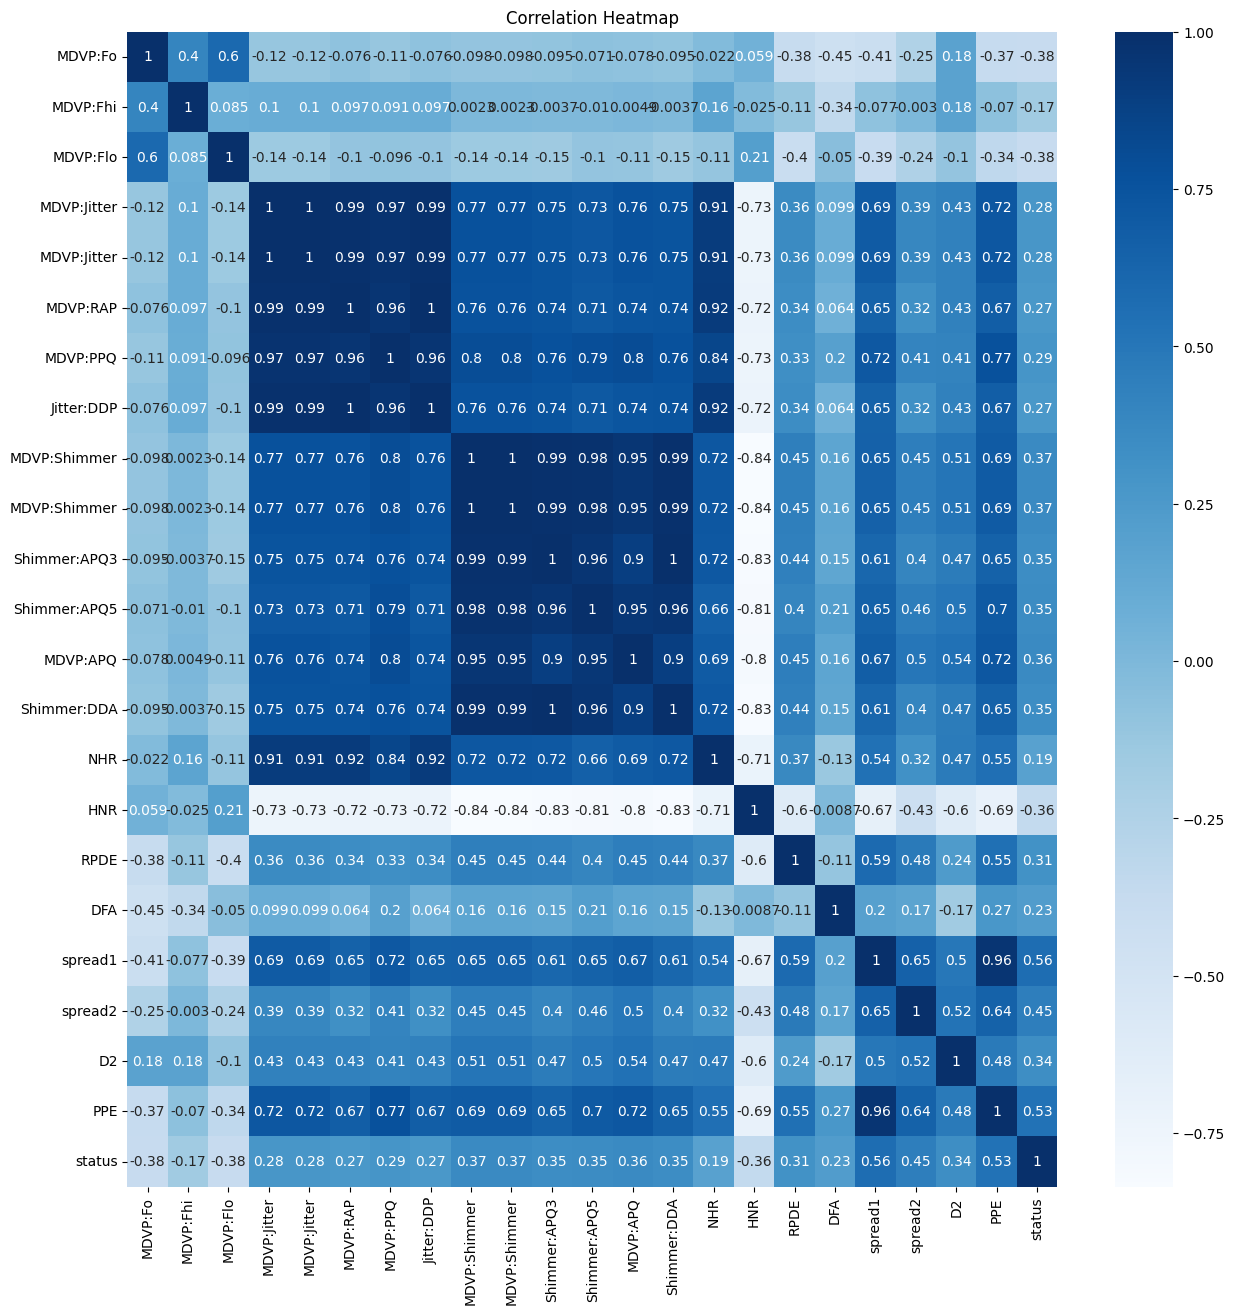

In [ ]:
plt.figure(figsize=(15,15))
sns.heatmap(parkinsons_df.corr(), annot=True, cmap="Blues")
plt.title('Correlation Heatmap')
plt.show()


# TEST TRAIN SPLIT

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
print("shape after tts:")
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)


shape after tts:
(156, 22) (39, 22) (156, 1) (39, 1)


# SCALING

* unscaled

In [ ]:
smote = SMOTE(random_state=42)
X_train_smote_raw, y_train_smote_raw = smote.fit_resample(X_train, y_train)
print("\n unscaled + smote ")
print(X_train_smote_raw.shape, y_train_smote_raw.shape)
print(pd.Series(np.ravel(y_train_smote_raw)).value_counts())


 unscaled + smote 
(236, 22) (236, 1)
0    118
1    118
Name: count, dtype: int64


* USING ROBUST SCALING

In [ ]:
scaler_robust = RobustScaler()
X_train_scaled = scaler_robust.fit_transform(X_train)
X_test_scaled = scaler_robust.transform(X_test)

In [ ]:
smote = SMOTE(random_state=42)
X_train_smote_A, y_train_smote_A = smote.fit_resample(X_train_scaled, y_train)

In [ ]:
print("\nrobustScaler + SMOTE:")
print(X_train_smote_A.shape, y_train_smote_A.shape)
print(pd.Series(y_train_smote_A.squeeze()).value_counts())



robustScaler + SMOTE:
(236, 22) (236, 1)
status
0    118
1    118
Name: count, dtype: int64


* quantile transformer

In [ ]:
qt = QuantileTransformer(output_distribution='normal', random_state=42)
X_train_qt = qt.fit_transform(X_train)
X_test_qt = qt.transform(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_data.py:2829: UserWarning: n_quantiles (1000) is greater than the total number of samples (156). n_quantiles is set to n_samples.
  warnings.warn(


In [ ]:
smote = SMOTE(random_state=42)
X_train_smote_qt, y_train_smote_qt = smote.fit_resample(X_train_qt, y_train)

In [ ]:
print("\nQuantileTransformer + SMOTE:")
print(X_train_smote_qt.shape, y_train_smote_qt.shape)
print(pd.Series(np.ravel(y_train_smote_qt)).value_counts())


QuantileTransformer + SMOTE:
(236, 22) (236, 1)
0    118
1    118
Name: count, dtype: int64


* MIN MAX SCALER

In [ ]:
minmax = MinMaxScaler()
X_train_mm = minmax.fit_transform(X_train)
X_test_mm = minmax.transform(X_test)


In [ ]:
smote = SMOTE(random_state=42)
X_train_smote_mm, y_train_smote_mm = smote.fit_resample(X_train_mm, y_train)

In [ ]:
print("\nMinMaxScaler + SMOTE:")
print(X_train_smote_mm.shape, y_train_smote_mm.shape)
print(pd.Series(np.ravel(y_train_smote_mm)).value_counts())


MinMaxScaler + SMOTE:
(236, 22) (236, 1)
0    118
1    118
Name: count, dtype: int64


* MAX ABS SCALER

In [ ]:
maxabs = MaxAbsScaler()
X_train_ma = maxabs.fit_transform(X_train)
X_test_ma = maxabs.transform(X_test)

In [ ]:
smote = SMOTE(random_state=42)
X_train_smote_ma, y_train_smote_ma = smote.fit_resample(X_train_ma, y_train)

In [ ]:
print("\nMaxAbsScaler + SMOTE:")
print(X_train_smote_ma.shape, y_train_smote_ma.shape)
print(pd.Series(np.ravel(y_train_smote_ma)).value_counts())



MaxAbsScaler + SMOTE:
(236, 22) (236, 1)
0    118
1    118
Name: count, dtype: int64


* VECTOR SCALING / NORMALIZER

In [ ]:
normalizer = Normalizer()
X_train_norm = normalizer.fit_transform(X_train)
X_test_norm = normalizer.transform(X_test)

In [ ]:
smote = SMOTE(random_state=42)
X_train_smote_norm, y_train_smote_norm = smote.fit_resample(X_train_norm, y_train)


In [ ]:
print("\n Normalizer + SMOTE:")
print(X_train_smote_norm.shape, y_train_smote_norm.shape)
print(pd.Series(np.ravel(y_train_smote_norm)).value_counts())



 Normalizer + SMOTE:
(236, 22) (236, 1)
0    118
1    118
Name: count, dtype: int64


* STANDARD SCALER

In [ ]:
standard = StandardScaler()
X_train_std = standard.fit_transform(X_train)
X_test_std = standard.transform(X_test)


In [ ]:
smote = SMOTE(random_state=42)
X_train_smote_std, y_train_smote_std = smote.fit_resample(X_train_std, y_train)

In [ ]:

print("\n StandardScaler + SMOTE:")
print(X_train_smote_std.shape, y_train_smote_std.shape)
print(pd.Series(np.ravel(y_train_smote_std)).value_counts())


 StandardScaler + SMOTE:
(236, 22) (236, 1)
0    118
1    118
Name: count, dtype: int64


* POWER TRANSFORMER


In [ ]:
power = PowerTransformer()
X_train_pow = power.fit_transform(X_train)
X_test_pow = power.transform(X_test)

In [ ]:
smote = SMOTE(random_state=42)
X_train_smote_pow, y_train_smote_pow = smote.fit_resample(X_train_pow, y_train)

In [ ]:
print("\n PowerTransformer + SMOTE:")
print(X_train_smote_pow.shape, y_train_smote_pow.shape)
print(pd.Series(np.ravel(y_train_smote_pow)).value_counts())


 PowerTransformer + SMOTE:
(236, 22) (236, 1)
0    118
1    118
Name: count, dtype: int64


# APPLYING ALGORITHMS

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import SGDClassifier
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

In [ ]:
pip install lightgbm xgboost


In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(random_state=42),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "Gradient Boost": GradientBoostingClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "LightGBM": LGBMClassifier(random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}


* unscaled

In [ ]:
print("\n unscaled + SMOTE =")

# Fix duplicate column names
X_train_smote_raw = pd.DataFrame(X_train_smote_raw)
X_train_smote_raw.columns = [f"{col}_{i}" for i, col in enumerate(X.columns)]
X_test_df = pd.DataFrame(X_test)
X_test_df.columns = [f"{col}_{i}" for i, col in enumerate(X.columns)]

for name, model in models.items():
    try:
        model.fit(X_train_smote_raw, y_train_smote_raw.values.ravel())  # flatten y
        y_pred = model.predict(X_test_df)
        print(f"\n{name} Accuracy: {accuracy_score(y_test, y_pred)}")
        print(classification_report(y_test, y_pred))
    except Exception as e:
        print(f"\n{name} failed → {e}")



 unscaled + SMOTE =

Logistic Regression Accuracy: 0.7948717948717948
              precision    recall  f1-score   support

           0       0.57      0.80      0.67        10
           1       0.92      0.79      0.85        29

    accuracy                           0.79        39
   macro avg       0.75      0.80      0.76        39
weighted avg       0.83      0.79      0.80        39


Decision Tree Accuracy: 0.7948717948717948
              precision    recall  f1-score   support

           0       0.60      0.60      0.60        10
           1       0.86      0.86      0.86        29

    accuracy                           0.79        39
   macro avg       0.73      0.73      0.73        39
weighted avg       0.79      0.79      0.79        39


Random Forest Accuracy: 0.8974358974358975
              precision    recall  f1-score   support

           0       0.75      0.90      0.82        10
           1       0.96      0.90      0.93        29

    accuracy           

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [14:53:23] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


* robust scaling

In [ ]:
print("\n RobustScaler + SMOTE ")

for name, model in models.items():
    model.fit(X_train_smote_A, y_train_smote_A)
    y_pred = model.predict(X_test_scaled)
    print(f"\n{name} Accuracy: {accuracy_score(y_test, y_pred)}")
    print(classification_report(y_test, y_pred))



 RobustScaler + SMOTE 

Logistic Regression Accuracy: 0.7692307692307693
              precision    recall  f1-score   support

           0       0.53      0.90      0.67        10
           1       0.95      0.72      0.82        29

    accuracy                           0.77        39
   macro avg       0.74      0.81      0.75        39
weighted avg       0.85      0.77      0.78        39


Decision Tree Accuracy: 0.6923076923076923
              precision    recall  f1-score   support

           0       0.43      0.60      0.50        10
           1       0.84      0.72      0.78        29

    accuracy                           0.69        39
   macro avg       0.63      0.66      0.64        39
weighted avg       0.73      0.69      0.71        39



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)



Random Forest Accuracy: 0.8717948717948718
              precision    recall  f1-score   support

           0       0.73      0.80      0.76        10
           1       0.93      0.90      0.91        29

    accuracy                           0.87        39
   macro avg       0.83      0.85      0.84        39
weighted avg       0.88      0.87      0.87        39


SVM Accuracy: 0.7692307692307693
              precision    recall  f1-score   support

           0       0.53      1.00      0.69        10
           1       1.00      0.69      0.82        29

    accuracy                           0.77        39
   macro avg       0.76      0.84      0.75        39
weighted avg       0.88      0.77      0.78        39


KNN Accuracy: 0.8461538461538461
              precision    recall  f1-score   support

           0       0.62      1.00      0.77        10
           1       1.00      0.79      0.88        29

    accuracy                           0.85        39
   macro avg    

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for ex


Gradient Boost Accuracy: 0.9487179487179487
              precision    recall  f1-score   support

           0       0.90      0.90      0.90        10
           1       0.97      0.97      0.97        29

    accuracy                           0.95        39
   macro avg       0.93      0.93      0.93        39
weighted avg       0.95      0.95      0.95        39


AdaBoost Accuracy: 0.8461538461538461
              precision    recall  f1-score   support

           0       0.67      0.80      0.73        10
           1       0.93      0.86      0.89        29

    accuracy                           0.85        39
   macro avg       0.80      0.83      0.81        39
weighted avg       0.86      0.85      0.85        39

[LightGBM] [Info] Number of positive: 118, number of negative: 118
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000100 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1751

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:93: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:129: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [14:53:25] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


* quantile

In [ ]:
print("\n QuantileTransformer + SMOTE ")

for name, model in models.items():
    model.fit(X_train_smote_qt, y_train_smote_qt)
    y_pred = model.predict(X_test_qt)
    print(f"\n{name} Accuracy: {accuracy_score(y_test, y_pred)}")
    print(classification_report(y_test, y_pred))



 QuantileTransformer + SMOTE 

Logistic Regression Accuracy: 0.8205128205128205
              precision    recall  f1-score   support

           0       0.62      0.80      0.70        10
           1       0.92      0.83      0.87        29

    accuracy                           0.82        39
   macro avg       0.77      0.81      0.78        39
weighted avg       0.84      0.82      0.83        39


Decision Tree Accuracy: 0.8461538461538461
              precision    recall  f1-score   support

           0       0.62      1.00      0.77        10
           1       1.00      0.79      0.88        29

    accuracy                           0.85        39
   macro avg       0.81      0.90      0.83        39
weighted avg       0.90      0.85      0.86        39



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)



Random Forest Accuracy: 0.8717948717948718
              precision    recall  f1-score   support

           0       0.69      0.90      0.78        10
           1       0.96      0.86      0.91        29

    accuracy                           0.87        39
   macro avg       0.83      0.88      0.85        39
weighted avg       0.89      0.87      0.88        39


SVM Accuracy: 0.8717948717948718
              precision    recall  f1-score   support

           0       0.67      1.00      0.80        10
           1       1.00      0.83      0.91        29

    accuracy                           0.87        39
   macro avg       0.83      0.91      0.85        39
weighted avg       0.91      0.87      0.88        39


KNN Accuracy: 0.8461538461538461
              precision    recall  f1-score   support

           0       0.62      1.00      0.77        10
           1       1.00      0.79      0.88        29

    accuracy                           0.85        39
   macro avg    

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for ex


Gradient Boost Accuracy: 0.9230769230769231
              precision    recall  f1-score   support

           0       0.82      0.90      0.86        10
           1       0.96      0.93      0.95        29

    accuracy                           0.92        39
   macro avg       0.89      0.92      0.90        39
weighted avg       0.93      0.92      0.92        39


AdaBoost Accuracy: 0.8205128205128205


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:93: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:129: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)


              precision    recall  f1-score   support

           0       0.62      0.80      0.70        10
           1       0.92      0.83      0.87        29

    accuracy                           0.82        39
   macro avg       0.77      0.81      0.78        39
weighted avg       0.84      0.82      0.83        39

[LightGBM] [Info] Number of positive: 118, number of negative: 118
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000131 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1757
[LightGBM] [Info] Number of data points in the train set: 236, number of used features: 22
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [War

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [14:53:26] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


* MinMaxScaler

In [ ]:
print("\n MinMaxScaler + SMOTE ")

for name, model in models.items():
    model.fit(X_train_smote_mm, y_train_smote_mm)
    y_pred = model.predict(X_test_mm)
    print(f"\n{name} Accuracy: {accuracy_score(y_test, y_pred)}")
    print(classification_report(y_test, y_pred))



 MinMaxScaler + SMOTE 

Logistic Regression Accuracy: 0.7435897435897436
              precision    recall  f1-score   support

           0       0.50      0.90      0.64        10
           1       0.95      0.69      0.80        29

    accuracy                           0.74        39
   macro avg       0.73      0.79      0.72        39
weighted avg       0.84      0.74      0.76        39



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)



Decision Tree Accuracy: 0.7692307692307693
              precision    recall  f1-score   support

           0       0.54      0.70      0.61        10
           1       0.88      0.79      0.84        29

    accuracy                           0.77        39
   macro avg       0.71      0.75      0.72        39
weighted avg       0.80      0.77      0.78        39


Random Forest Accuracy: 0.8717948717948718
              precision    recall  f1-score   support

           0       0.73      0.80      0.76        10
           1       0.93      0.90      0.91        29

    accuracy                           0.87        39
   macro avg       0.83      0.85      0.84        39
weighted avg       0.88      0.87      0.87        39


SVM Accuracy: 0.7948717948717948
              precision    recall  f1-score   support

           0       0.56      1.00      0.71        10
           1       1.00      0.72      0.84        29

    accuracy                           0.79        39
   mac

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for ex


Gradient Boost Accuracy: 0.9230769230769231
              precision    recall  f1-score   support

           0       0.82      0.90      0.86        10
           1       0.96      0.93      0.95        29

    accuracy                           0.92        39
   macro avg       0.89      0.92      0.90        39
weighted avg       0.93      0.92      0.92        39


AdaBoost Accuracy: 0.8974358974358975


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:93: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:129: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)


              precision    recall  f1-score   support

           0       0.75      0.90      0.82        10
           1       0.96      0.90      0.93        29

    accuracy                           0.90        39
   macro avg       0.86      0.90      0.87        39
weighted avg       0.91      0.90      0.90        39

[LightGBM] [Info] Number of positive: 118, number of negative: 118
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000093 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1744
[LightGBM] [Info] Number of data points in the train set: 236, number of used features: 22
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [War

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [14:53:27] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


* MaxAbsScaler

In [ ]:
print("\n MaxAbsScaler + SMOTE ")
for name, model in models.items():
    model.fit(X_train_smote_ma, y_train_smote_ma)
    y_pred = model.predict(X_test_ma)
    print(f"\n{name} Accuracy: {accuracy_score(y_test, y_pred)}")
    print(classification_report(y_test, y_pred))


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)



 MaxAbsScaler + SMOTE 

Logistic Regression Accuracy: 0.7435897435897436
              precision    recall  f1-score   support

           0       0.50      1.00      0.67        10
           1       1.00      0.66      0.79        29

    accuracy                           0.74        39
   macro avg       0.75      0.83      0.73        39
weighted avg       0.87      0.74      0.76        39


Decision Tree Accuracy: 0.8205128205128205
              precision    recall  f1-score   support

           0       0.60      0.90      0.72        10
           1       0.96      0.79      0.87        29

    accuracy                           0.82        39
   macro avg       0.78      0.85      0.79        39
weighted avg       0.87      0.82      0.83        39



/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)



Random Forest Accuracy: 0.8974358974358975
              precision    recall  f1-score   support

           0       0.80      0.80      0.80        10
           1       0.93      0.93      0.93        29

    accuracy                           0.90        39
   macro avg       0.87      0.87      0.87        39
weighted avg       0.90      0.90      0.90        39


SVM Accuracy: 0.6923076923076923
              precision    recall  f1-score   support

           0       0.45      1.00      0.62        10
           1       1.00      0.59      0.74        29

    accuracy                           0.69        39
   macro avg       0.73      0.79      0.68        39
weighted avg       0.86      0.69      0.71        39


KNN Accuracy: 0.9230769230769231
              precision    recall  f1-score   support

           0       0.77      1.00      0.87        10
           1       1.00      0.90      0.95        29

    accuracy                           0.92        39
   macro avg    

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for ex


Gradient Boost Accuracy: 0.9487179487179487
              precision    recall  f1-score   support

           0       0.90      0.90      0.90        10
           1       0.97      0.97      0.97        29

    accuracy                           0.95        39
   macro avg       0.93      0.93      0.93        39
weighted avg       0.95      0.95      0.95        39



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)



AdaBoost Accuracy: 0.8205128205128205
              precision    recall  f1-score   support

           0       0.62      0.80      0.70        10
           1       0.92      0.83      0.87        29

    accuracy                           0.82        39
   macro avg       0.77      0.81      0.78        39
weighted avg       0.84      0.82      0.83        39

[LightGBM] [Info] Number of positive: 118, number of negative: 118
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000140 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1745
[LightGBM] [Info] Number of data points in the train set: 236, number of used features: 22
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positiv

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:93: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:129: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [14:53:29] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



XGBoost Accuracy: 0.9230769230769231
              precision    recall  f1-score   support

           0       0.82      0.90      0.86        10
           1       0.96      0.93      0.95        29

    accuracy                           0.92        39
   macro avg       0.89      0.92      0.90        39
weighted avg       0.93      0.92      0.92        39



* Normalizer

In [ ]:
print("\n Normalizer + SMOTE ")

for name, model in models.items():
    model.fit(X_train_smote_norm, y_train_smote_norm)
    y_pred = model.predict(X_test_norm)
    print(f"\n{name} Accuracy: {accuracy_score(y_test, y_pred)}")
    print(classification_report(y_test, y_pred))



 Normalizer + SMOTE 

Logistic Regression Accuracy: 0.358974358974359
              precision    recall  f1-score   support

           0       0.22      0.60      0.32        10
           1       0.67      0.28      0.39        29

    accuracy                           0.36        39
   macro avg       0.44      0.44      0.36        39
weighted avg       0.55      0.36      0.37        39


Decision Tree Accuracy: 0.7692307692307693
              precision    recall  f1-score   support

           0       0.53      0.90      0.67        10
           1       0.95      0.72      0.82        29

    accuracy                           0.77        39
   macro avg       0.74      0.81      0.75        39
weighted avg       0.85      0.77      0.78        39



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)



Random Forest Accuracy: 0.8717948717948718
              precision    recall  f1-score   support

           0       0.73      0.80      0.76        10
           1       0.93      0.90      0.91        29

    accuracy                           0.87        39
   macro avg       0.83      0.85      0.84        39
weighted avg       0.88      0.87      0.87        39


SVM Accuracy: 0.358974358974359
              precision    recall  f1-score   support

           0       0.22      0.60      0.32        10
           1       0.67      0.28      0.39        29

    accuracy                           0.36        39
   macro avg       0.44      0.44      0.36        39
weighted avg       0.55      0.36      0.37        39


KNN Accuracy: 0.6923076923076923
              precision    recall  f1-score   support

           0       0.44      0.70      0.54        10
           1       0.87      0.69      0.77        29

    accuracy                           0.69        39
   macro avg     

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for ex


Gradient Boost Accuracy: 0.8717948717948718
              precision    recall  f1-score   support

           0       0.73      0.80      0.76        10
           1       0.93      0.90      0.91        29

    accuracy                           0.87        39
   macro avg       0.83      0.85      0.84        39
weighted avg       0.88      0.87      0.87        39



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)



AdaBoost Accuracy: 0.9230769230769231
              precision    recall  f1-score   support

           0       0.82      0.90      0.86        10
           1       0.96      0.93      0.95        29

    accuracy                           0.92        39
   macro avg       0.89      0.92      0.90        39
weighted avg       0.93      0.92      0.92        39

[LightGBM] [Info] Number of positive: 118, number of negative: 118
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000097 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1760
[LightGBM] [Info] Number of data points in the train set: 236, number of used features: 22
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positiv

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:93: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:129: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [14:53:30] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


* StandardScaler


In [ ]:
print("\n StandardScaler + SMOTE ")

for name, model in models.items():
    model.fit(X_train_smote_std, y_train_smote_std)
    y_pred = model.predict(X_test_std)
    print(f"\n{name} Accuracy: {accuracy_score(y_test, y_pred)}")
    print(classification_report(y_test, y_pred))



 StandardScaler + SMOTE 

Logistic Regression Accuracy: 0.7692307692307693
              precision    recall  f1-score   support

           0       0.53      0.90      0.67        10
           1       0.95      0.72      0.82        29

    accuracy                           0.77        39
   macro avg       0.74      0.81      0.75        39
weighted avg       0.85      0.77      0.78        39


Decision Tree Accuracy: 0.7948717948717948
              precision    recall  f1-score   support

           0       0.57      0.80      0.67        10
           1       0.92      0.79      0.85        29

    accuracy                           0.79        39
   macro avg       0.75      0.80      0.76        39
weighted avg       0.83      0.79      0.80        39



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)



Random Forest Accuracy: 0.8974358974358975
              precision    recall  f1-score   support

           0       0.75      0.90      0.82        10
           1       0.96      0.90      0.93        29

    accuracy                           0.90        39
   macro avg       0.86      0.90      0.87        39
weighted avg       0.91      0.90      0.90        39


SVM Accuracy: 0.8461538461538461
              precision    recall  f1-score   support

           0       0.62      1.00      0.77        10
           1       1.00      0.79      0.88        29

    accuracy                           0.85        39
   macro avg       0.81      0.90      0.83        39
weighted avg       0.90      0.85      0.86        39


KNN Accuracy: 0.9230769230769231
              precision    recall  f1-score   support

           0       0.77      1.00      0.87        10
           1       1.00      0.90      0.95        29

    accuracy                           0.92        39
   macro avg    

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for ex


Gradient Boost Accuracy: 0.9487179487179487
              precision    recall  f1-score   support

           0       0.90      0.90      0.90        10
           1       0.97      0.97      0.97        29

    accuracy                           0.95        39
   macro avg       0.93      0.93      0.93        39
weighted avg       0.95      0.95      0.95        39


AdaBoost Accuracy: 0.7948717948717948
              precision    recall  f1-score   support

           0       0.56      0.90      0.69        10
           1       0.96      0.76      0.85        29

    accuracy                           0.79        39
   macro avg       0.76      0.83      0.77        39
weighted avg       0.86      0.79      0.81        39



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:93: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:129: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)


[LightGBM] [Info] Number of positive: 118, number of negative: 118
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000154 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1755
[LightGBM] [Info] Number of data points in the train set: 236, number of used features: 22
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits wit

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [14:53:32] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


* PowerTransformer

In [ ]:
print("\n=== PowerTransformer + SMOTE ===")

for name, model in models.items():
    model.fit(X_train_smote_pow, y_train_smote_pow)
    y_pred = model.predict(X_test_pow)
    print(f"\n{name} Accuracy: {accuracy_score(y_test, y_pred)}")
    print(classification_report(y_test, y_pred))



=== PowerTransformer + SMOTE ===

Logistic Regression Accuracy: 0.8461538461538461
              precision    recall  f1-score   support

           0       0.67      0.80      0.73        10
           1       0.93      0.86      0.89        29

    accuracy                           0.85        39
   macro avg       0.80      0.83      0.81        39
weighted avg       0.86      0.85      0.85        39


Decision Tree Accuracy: 0.7435897435897436
              precision    recall  f1-score   support

           0       0.50      0.70      0.58        10
           1       0.88      0.76      0.81        29

    accuracy                           0.74        39
   macro avg       0.69      0.73      0.70        39
weighted avg       0.78      0.74      0.76        39



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)



Random Forest Accuracy: 0.8717948717948718
              precision    recall  f1-score   support

           0       0.73      0.80      0.76        10
           1       0.93      0.90      0.91        29

    accuracy                           0.87        39
   macro avg       0.83      0.85      0.84        39
weighted avg       0.88      0.87      0.87        39


SVM Accuracy: 0.8717948717948718
              precision    recall  f1-score   support

           0       0.67      1.00      0.80        10
           1       1.00      0.83      0.91        29

    accuracy                           0.87        39
   macro avg       0.83      0.91      0.85        39
weighted avg       0.91      0.87      0.88        39


KNN Accuracy: 0.8974358974358975
              precision    recall  f1-score   support

           0       0.71      1.00      0.83        10
           1       1.00      0.86      0.93        29

    accuracy                           0.90        39
   macro avg    

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for ex


Gradient Boost Accuracy: 0.9487179487179487
              precision    recall  f1-score   support

           0       0.90      0.90      0.90        10
           1       0.97      0.97      0.97        29

    accuracy                           0.95        39
   macro avg       0.93      0.93      0.93        39
weighted avg       0.95      0.95      0.95        39


AdaBoost Accuracy: 0.8974358974358975
              precision    recall  f1-score   support

           0       0.75      0.90      0.82        10
           1       0.96      0.90      0.93        29

    accuracy                           0.90        39
   macro avg       0.86      0.90      0.87        39
weighted avg       0.91      0.90      0.90        39

[LightGBM] [Info] Number of positive: 118, number of negative: 118
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000089 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1753

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:93: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:129: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [14:53:33] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [ ]:
model_results = {
    "Unscaled": (X_train_smote_raw, y_train_smote_raw, X_test),
    "RobustScaler": (X_train_smote_A, y_train_smote_A, X_test_scaled),
    "QuantileTransformer": (X_train_smote_qt, y_train_smote_qt, X_test_qt),
    "MinMaxScaler": (X_train_smote_mm, y_train_smote_mm, X_test_mm),
    "MaxAbsScaler": (X_train_smote_ma, y_train_smote_ma, X_test_ma),
    "Normalizer": (X_train_smote_norm, y_train_smote_norm, X_test_norm),
    "StandardScaler": (X_train_smote_std, y_train_smote_std, X_test_std),
    "PowerTransformer": (X_train_smote_pow, y_train_smote_pow, X_test_pow)
}

results = []

for scaler_name, (X_tr, y_tr, X_te) in model_results.items():
    # Convert to DataFrame if not already
    if not isinstance(X_tr, pd.DataFrame):
        X_tr = pd.DataFrame(X_tr, columns=[f"{col}_{i}" for i, col in enumerate(X.columns)])
    if not isinstance(X_te, pd.DataFrame):
        X_te = pd.DataFrame(X_te, columns=[f"{col}_{i}" for i, col in enumerate(X.columns)])

    # Fix any special characters in column names
    X_tr.columns = X_tr.columns.str.replace('[^A-Za-z0-9_]+', '_', regex=True)
    X_te.columns = X_te.columns.str.replace('[^A-Za-z0-9_]+', '_', regex=True)

    print(f"\n=== {scaler_name} ===")

    for model_name, model in models.items():
        try:
            model.fit(X_tr, y_tr.values.ravel() if isinstance(y_tr, pd.DataFrame) else y_tr)
            y_pred = model.predict(X_te)
            acc = accuracy_score(y_test, y_pred)

            results.append({
                "Scaler": scaler_name,
                "Algorithm": model_name,
                "Accuracy": acc
            })

            print(f"{scaler_name} + {model_name}: {acc:.4f}")

        except Exception as e:
            print(f"{scaler_name} + {model_name} → Error: {e}")


results_df = pd.DataFrame(results)

accuracy_table = results_df.pivot(index="Scaler", columns="Algorithm", values="Accuracy")

print("\n=== Accuracy Comparison Table ===")
print(accuracy_table)



=== Unscaled ===
Unscaled + Logistic Regression → Error: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- D2
- DFA
- HNR
- Jitter_DDP
- MDVP_APQ
- ...
Feature names seen at fit time, yet now missing:
- D2_20
- DFA_17
- HNR_15
- Jitter_DDP_7
- MDVP_APQ_12
- ...

Unscaled + Decision Tree → Error: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- D2
- DFA
- HNR
- Jitter_DDP
- MDVP_APQ
- ...
Feature names seen at fit time, yet now missing:
- D2_20
- DFA_17
- HNR_15
- Jitter_DDP_7
- MDVP_APQ_12
- ...

Unscaled + Random Forest → Error: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- D2
- DFA
- HNR
- Jitter_DDP
- MDVP_APQ
- ...
Feature names seen at fit time, yet now missing:
- D2_20
- DFA_17
- HNR_15
- Jitter_DDP_7
- MDVP_APQ_12
- ...

Unscaled + SVM → Error: The feature names should match those that were passed during fit.
Feature na

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [14:53:34] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


RobustScaler + Random Forest: 0.8718
RobustScaler + SVM: 0.7692
RobustScaler + KNN: 0.8462
RobustScaler + Naive Bayes: 0.6410
RobustScaler + Gradient Boost: 0.9487
RobustScaler + AdaBoost: 0.8462
[LightGBM] [Info] Number of positive: 118, number of negative: 118
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000121 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1751
[LightGBM] [Info] Number of data points in the train set: 236, number of used features: 22
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [14:53:35] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


QuantileTransformer + Random Forest: 0.8718
QuantileTransformer + SVM: 0.8718
QuantileTransformer + KNN: 0.8462
QuantileTransformer + Naive Bayes: 0.6923
QuantileTransformer + Gradient Boost: 0.9231
QuantileTransformer + AdaBoost: 0.8205
[LightGBM] [Info] Number of positive: 118, number of negative: 118
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000103 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1757
[LightGBM] [Info] Number of data points in the train set: 236, number of used features: 22
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No furth

...

StandardScaler + Random Forest: 0.8974
StandardScaler + SVM: 0.8462
StandardScaler + KNN: 0.9231
StandardScaler + Naive Bayes: 0.6154
StandardScaler + Gradient Boost: 0.9487
StandardScaler + AdaBoost: 0.7949
[LightGBM] [Info] Number of positive: 118, number of negative: 118
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000143 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1755
[LightGBM] [Info] Number of data points in the train set: 236, number of used features: 22
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [14:53:40] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


StandardScaler + XGBoost: 0.8974

=== PowerTransformer ===
PowerTransformer + Logistic Regression: 0.8462
PowerTransformer + Decision Tree: 0.7436
PowerTransformer + Random Forest: 0.8718
PowerTransformer + SVM: 0.8718
PowerTransformer + KNN: 0.8974
PowerTransformer + Naive Bayes: 0.6410
PowerTransformer + Gradient Boost: 0.9487
PowerTransformer + AdaBoost: 0.8974
[LightGBM] [Info] Number of positive: 118, number of negative: 118
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000142 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1753
[LightGBM] [Info] Number of data points in the train set: 236, number of used features: 22
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positi

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [14:53:42] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


PowerTransformer + XGBoost: 0.9231

=== Accuracy Comparison Table ===
Algorithm            AdaBoost  Decision Tree  Gradient Boost       KNN  \
Scaler                                                                   
MaxAbsScaler         0.820513       0.820513        0.948718  0.923077   
MinMaxScaler         0.897436       0.769231        0.923077  0.923077   
Normalizer           0.923077       0.769231        0.871795  0.692308   
PowerTransformer     0.897436       0.743590        0.948718  0.897436   
QuantileTransformer  0.820513       0.846154        0.923077  0.846154   
RobustScaler         0.846154       0.692308        0.948718  0.846154   
StandardScaler       0.794872       0.794872        0.948718  0.923077   
Unscaled                  NaN            NaN             NaN       NaN   

Algorithm            LightGBM  Logistic Regression  Naive Bayes  \
Scaler                                                            
MaxAbsScaler         0.897436             0.743590     